In [1]:
import logging
import pandas as pd
import numpy as np
import os

logging.basicConfig(level=logging.INFO)

class FileValidationError(Exception):
    pass

class FileMissingValueError(FileValidationError):
    pass

def load_results(filepath: str) -> pd.DataFrame:
    if not os.path.exists(filepath):
        raise FileValidationError("File not found!!")  
    elif os.path.getsize(filepath) == 0:
        raise FileMissingValueError("File exists but contains no value or data")
    else:
        df = pd.read_csv(filepath, encoding='utf-8-sig')
        logging.info(f"Loaded {filepath} — shape: {df.shape}")
        return df

try:
    al = load_results("data/raw/Allocated Limit for Honble MPs.csv")
    wc = load_results("data/raw/Works Completed.csv")
    ws = load_results("data/raw/Works Sanctioned.csv")

except FileValidationError as e:
    logging.error(f"Loading Failed: {e}")
    raise

INFO:root:Loaded data/raw/Allocated Limit for Honble MPs.csv — shape: (544, 5)
INFO:root:Loaded data/raw/Works Completed.csv — shape: (15001, 11)
INFO:root:Loaded data/raw/Works Sanctioned.csv — shape: (6001, 12)


In [2]:
import re

al = al.iloc[:-1]
ws = ws.iloc[:-1]
wc = wc.iloc[:-1]

def clean_dataframe_columns(df: pd.DataFrame) -> pd.DataFrame:
    
    dfCols = list(df.columns)
    columns_cleaned = []

    for col in dfCols:
        cleaned_names = re.sub("[\.\'\()\₹]", '',str(col)).lower().strip()
        cleaned_names = cleaned_names.replace(" ", "_")
        columns_cleaned.append(cleaned_names)

    df.columns = (columns_cleaned)
    return df


clean_dataframe_columns(al).columns
clean_dataframe_columns(wc).columns
clean_dataframe_columns(ws).columns

Index(['sr_no', 'work_category', 'work', 'state', 'ida',
       'honble_members_of_parliament', 'constituency', 'work_description',
       'recommended_date', 'sanction_date', 'sanction_amount', 'work_status'],
      dtype='object')

In [3]:
al.columns, ws.columns, wc.columns

(Index(['sr_no', 'state', 'honble_members_of_parliaments', 'constituency',
        'allocated_amount'],
       dtype='object'),
 Index(['sr_no', 'work_category', 'work', 'state', 'ida',
        'honble_members_of_parliament', 'constituency', 'work_description',
        'recommended_date', 'sanction_date', 'sanction_amount', 'work_status'],
       dtype='object'),
 Index(['sr_no', 'work_category', 'work', 'state', 'ida', 'work_description',
        'honble_members_of_parliament', 'constituency', 'image',
        'completion_date', 'amount_disbursed'],
       dtype='object'))

In [4]:
def diagnose_dataframe(df: pd.DataFrame, name: str):
    logging.info(f"\n Dataframe -> {name}\n")
    logging.info(f" Shape: \n{df.shape}\n")
    logging.info(f" Dataframe Datatypes \n{df.dtypes}\n")
    logging.info(f" Dataframe null columns \n{df.isna().sum()[df.isna().sum()>0]}\n")
    logging.info(f" Datarframe duplicates \n{df.duplicated().sum()}")

    
diagnose_dataframe(al, "Allocated Limit for Honble MPs")
diagnose_dataframe(wc, "Works Completed")
diagnose_dataframe(ws, "Works Sanctioned")

INFO:root:
 Dataframe -> Allocated Limit for Honble MPs

INFO:root: Shape: 
(543, 5)

INFO:root: Dataframe Datatypes 
sr_no                            object
state                            object
honble_members_of_parliaments    object
constituency                     object
allocated_amount                 object
dtype: object

INFO:root: Dataframe null columns 
allocated_amount    1
dtype: int64

INFO:root: Datarframe duplicates 
0
INFO:root:
 Dataframe -> Works Completed

INFO:root: Shape: 
(15000, 11)

INFO:root: Dataframe Datatypes 
sr_no                           object
work_category                   object
work                            object
state                           object
ida                             object
work_description                object
honble_members_of_parliament    object
constituency                    object
image                           object
completion_date                 object
amount_disbursed                object
dtype: object

INFO:root:

In [5]:
print(al.isna().sum()[al.isna().sum()>0])
print(wc.isna().sum()[wc.isna().sum()>0])
print(ws.isna().sum()[ws.isna().sum()>0])

allocated_amount    1
dtype: int64
work_description      55
image               5054
amount_disbursed       6
dtype: int64
work_description    38
dtype: int64


In [6]:
def numeric_conversion(df:pd.DataFrame, columns: list) -> pd.DataFrame:
    for cols in columns:
        df[cols] = pd.to_numeric(df[cols], errors="coerce", downcast="float")
    return df

al = numeric_conversion(al, ["allocated_amount"])
wc = numeric_conversion(wc, ["amount_disbursed"])
ws = numeric_conversion(ws, ["sanction_amount"])

In [7]:
print(al.isna().sum()[al.isna().sum()>0])
print(wc.isna().sum()[wc.isna().sum()>0])
print(ws.isna().sum()[ws.isna().sum()>0])

allocated_amount    1
dtype: int64
work_description      55
image               5054
amount_disbursed       6
dtype: int64
work_description    38
dtype: int64


In [8]:
def replace_strings_with_real_nulls(df: pd.DataFrame) -> pd.DataFrame:
    df = df.replace("NaN", np.nan)
    return df
    
al = replace_strings_with_real_nulls(al)
wc = replace_strings_with_real_nulls(wc)
ws = replace_strings_with_real_nulls(ws)

In [9]:
def strip_whitespace(df: pd.DataFrame) -> pd.DataFrame:
    for col_name in df.columns:
        if df[col_name].dtype == "object":
            df[col_name] = df[col_name].str.strip()
            df[col_name] = df[col_name].str.replace(r"\t", " ", regex=True) 

    return df

al = strip_whitespace(al)
wc = strip_whitespace(wc)
ws = strip_whitespace(ws)

# al.style.format({"allocated_amount": "{:,.2f}"})
# wc.style.format({"amount_disbursed": "{:,.2f}"})
# wc.style.format({"sanction_amount": "{:,.2f}"})
# DO-NOT UNCOMMENT THESE!!

In [10]:
def convert_real_datetime(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    for cols in columns:
        initial_count =  df[cols].isna().sum()
        df[cols] = pd.to_datetime(df[cols], errors="coerce",  format="%d-%b-%Y")
        failed_count = df[cols].isna().sum()
        failed = failed_count - initial_count
        logging.info(f"Column '{cols}': {failed} unparseable entries turned into NaT.")
    return df

wc_datetime_list = ["completion_date"]
ws_datetime_list = ["recommended_date", "sanction_date"]
wc = convert_real_datetime(wc, wc_datetime_list)
ws = convert_real_datetime(ws, ws_datetime_list)

INFO:root:Column 'completion_date': 0 unparseable entries turned into NaT.
INFO:root:Column 'recommended_date': 0 unparseable entries turned into NaT.
INFO:root:Column 'sanction_date': 0 unparseable entries turned into NaT.


In [11]:
def drop_duplicate_rows(df: pd.DataFrame, name: str) -> pd.DataFrame:
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]
    logging.info(f"{name}: dropped {before - after} duplicate rows")
    return df

al = drop_duplicate_rows(al, "Allocated Limit")
ws = drop_duplicate_rows(ws, "Works Sanctioned")
wc = drop_duplicate_rows(wc, "Works Completed")

INFO:root:Allocated Limit: dropped 0 duplicate rows
INFO:root:Works Sanctioned: dropped 0 duplicate rows
INFO:root:Works Completed: dropped 0 duplicate rows


In [12]:
al = al.drop(columns=["sr_no"])
ws = ws.drop(columns=["sr_no"])
wc = wc.drop(columns=["sr_no", "image"])

In [13]:
diagnose_dataframe(al, "Allocated Limit (cleaned)")
diagnose_dataframe(ws, "Works Sanctioned (cleaned)")
diagnose_dataframe(wc, "Works Completed (cleaned)")

INFO:root:
 Dataframe -> Allocated Limit (cleaned)

INFO:root: Shape: 
(543, 4)

INFO:root: Dataframe Datatypes 
state                             object
honble_members_of_parliaments     object
constituency                      object
allocated_amount                 float64
dtype: object

INFO:root: Dataframe null columns 
allocated_amount    1
dtype: int64

INFO:root: Datarframe duplicates 
0
INFO:root:
 Dataframe -> Works Sanctioned (cleaned)

INFO:root: Shape: 
(6000, 11)

INFO:root: Dataframe Datatypes 
work_category                           object
work                                    object
state                                   object
ida                                     object
honble_members_of_parliament            object
constituency                            object
work_description                        object
recommended_date                datetime64[ns]
sanction_date                   datetime64[ns]
sanction_amount                        float64
work_status    

In [14]:
wc

,work_category,work,state,ida,work_description,honble_members_of_parliament,constituency,completion_date,amount_disbursed
0,Normal/Others,WS/MP418/2024-2025/133409-Construction of road...,Bihar,ARARIA(DISTRICT PLANNING OFFICER ARARIA_IDA),PCC Road from Permeshwar Bhagat house to Ramde...,Pradeep Kumar Singh,ARARIA,2024-09-05,448127.0
1,Normal/Others,WS/MP18152/2024-2025/133691-Construction of ro...,Punjab,FARIDKOT(DEPUTY COMMISSIONER FARIDKOT_IDA),Construction of MID DAY Meal Shed in Govt Prim...,SARABJEET SINGH KHALSA,FARIDKOT(SC),2025-04-07,300000.0
2,Normal/Others,WS/MP345/2024-2025/134140-Construction of road...,Kerala,KOLLAM(DISTRICT COLLECTOR KOLLAM_IDA),Concreting of road from Janathavayanasala - P...,Shri NK Premachandran,KOLLAM,2024-08-12,293492.0
3,Normal/Others,WS/MP18152/2024-2025/133686-Construction of ro...,Punjab,FARIDKOT(DEPUTY COMMISSIONER FARIDKOT_IDA),Construction of MID DAY Meal Shed in Govt Prim...,SARABJEET SINGH KHALSA,FARIDKOT(SC),2025-04-07,300000.0
4,Normal/Others,WS/MP18152/2024-2025/133690-Construction of ro...,Punjab,FARIDKOT(DEPUTY COMMISSIONER FARIDKOT_IDA),Construction of MID DAY Meal Shed in Govt Prim...,SARABJEET SINGH KHALSA,FARIDKOT(SC),2025-04-07,300000.0
...,...,...,...,...,...,...,...,...,...
14995,Normal/Others,WS/MP797/2025-2026/218229-Installation of fixe...,Uttar Pradesh,FARRUKHABAD(DISTRICT MAGISTRAE FARRUKHABAD_IDA),Establishment of an open gym at Shriram Shiksh...,Mukesh Rajput,FARRUKHABAD,2025-12-03,822505.0
14996,Normal/Others,WS/MP18344/2025-2026/176584-Construction of ro...,Gujarat,RAJKOT(DISTRICT COLLECTOR RAJKOT_IDA),Paver block work from Bus Station to Ram Mandir,DR. MANSUKH MANDAVIYA,PORBANDAR,2025-09-13,400000.0
14997,Normal/Others,WS/MP797/2025-2026/218228-Installation of fixe...,Uttar Pradesh,FARRUKHABAD(DISTRICT MAGISTRAE FARRUKHABAD_IDA),Establishment of an open gym at a public place...,Mukesh Rajput,FARRUKHABAD,2025-12-03,822505.0
14998,Normal/Others,WS/MP574/2025-2026/219836-Purchase of smart bo...,Gujarat,PATAN(DISTRICT COLLECTOR PATAN_IDA),SMART CLASS WORK IN UNDRA PRIMARY SCHOOL,Bharatsinhji Shankarji Dabhi,PATAN,2025-09-08,498875.0


al

In [15]:
def mp_name_clean(raw_name: str) -> str:
    cleaned_name = re.sub(r"^(Shri|Smt|Dr\.|Er\.)\s*", "", raw_name).upper()
    return cleaned_name

# al2 = al.copy()
# al2["honble_members_of_parliaments"] = al2["honble_members_of_parliaments"].apply(normalize_mp_name)

al["honble_members_of_parliaments"] = al["honble_members_of_parliaments"].apply(mp_name_clean)
ws["honble_members_of_parliament"] = ws["honble_members_of_parliament"].apply(mp_name_clean)
wc["honble_members_of_parliament"] = wc["honble_members_of_parliament"].apply(mp_name_clean)

In [16]:
al_set = set(al["honble_members_of_parliaments"].unique())
ws_set = set(ws["honble_members_of_parliament"].unique())
wc_set = set(wc["honble_members_of_parliament"].unique())

ws_matches = ws_set.intersection(al_set)
wc_matches = wc_set.intersection(al_set)

sanctioned_match_rate = len(ws_matches) / len(ws_set) if ws_set else 0.0
completed_match_rate = len(wc_matches) / len(wc_set) if wc_set else 0.0

logging.info("--- Overlap Summary ---")
logging.info(f"Sanctioned: {len(ws_matches)} names match Allocated out of {len(ws_set)} total.")
logging.info(f"Sanctioned Match Rate: {sanctioned_match_rate:.2%}")

logging.info(f"Completed: {len(wc_matches)} names match Allocated out of {len(wc_set)} total.")
logging.info(f"Completed Match Rate: {completed_match_rate:.2%}")

if sanctioned_match_rate < 0.90:
    logging.warning(f"Low match rate in Sanctioned! Sample of unmatched names: {list(ws_set - al_set)[:15]}")

if completed_match_rate < 0.90:
    logging.warning(f"Low match rate in Completed! Sample of unmatched names: {list(wc_set - al_set)[:15]}")

INFO:root:--- Overlap Summary ---
INFO:root:Sanctioned: 211 names match Allocated out of 211 total.
INFO:root:Sanctioned Match Rate: 100.00%
INFO:root:Completed: 416 names match Allocated out of 416 total.
INFO:root:Completed Match Rate: 100.00%


In [17]:
def grouping_by_mps(df: pd.DataFrame, grouping_column: str, amount_column: str) -> pd.DataFrame:
    return df.groupby(grouping_column).agg(
    total_sanction_amount=(amount_column, "sum"),
    sanction_work_count=(amount_column, "count")
)

test_ws = grouping_by_mps(ws, "honble_members_of_parliament", "sanction_amount")
test_wc = grouping_by_mps(wc, "honble_members_of_parliament", "amount_disbursed")

test_wc.rename(columns={"total_sanction_amount": "total_amount_disbursed"}, inplace=True)
# Minor Issuse fixed now.
al.rename(columns={"honble_members_of_parliaments": "honble_members_of_parliament"}, inplace=True)

In [18]:
step_1 = pd.merge(al, test_ws, on="honble_members_of_parliament", how="left")
final_merged = pd.merge(step_1, test_wc, on="honble_members_of_parliament", how="left")

final_merged = final_merged.rename(columns={
    "sanction_work_count_x": "sanctioned_work_count",
    "sanction_work_count_y": "completed_work_count",
    "total_amount_disbursed": "total_disbursed_amount"
})

cols_to_fill = ["total_sanction_amount", "sanctioned_work_count", "total_disbursed_amount", "completed_work_count"]
final_merged[cols_to_fill] = final_merged[cols_to_fill].fillna(0)

In [19]:
print(final_merged.shape)
zero_activity = final_merged[(final_merged["sanctioned_work_count"] == 0) & (final_merged["completed_work_count"] == 0)]
print(f"MPs with zero sanctioned and zero completed works: {len(zero_activity)}")
orphans = final_merged[(final_merged["sanctioned_work_count"] == 0) & (final_merged["completed_work_count"] > 0)]
print(f"MPs with completed works but zero matching sanctions: {len(orphans)}")

(543, 8)
MPs with zero sanctioned and zero completed works: 115
MPs with completed works but zero matching sanctions: 217


In [20]:
df = final_merged.copy()
df["utiliazation_rate"] = df["total_disbursed_amount"] / df["allocated_amount"]
df["sanctioned_backlog"] = df["total_sanction_amount"] - df["total_disbursed_amount"]
df["completion_ratio"] = np.where(df["sanctioned_work_count"] == 0, np.nan, df["completed_work_count"] / df["sanctioned_work_count"])
df["has_no_activity"] = (df["sanctioned_work_count"] == 0) & (df["completed_work_count"] == 0)
# an MP who shows completed, disbursed works in the Completed table, but has zero matching sanctioned works in the Sanctioned table.
df["has_orphan_completions"] = (df["sanctioned_work_count"] == 0) & (df["completed_work_count"] > 0)

In [21]:
state_summary = df.groupby("state").agg(
        avg_utiliazation_rate=("utiliazation_rate","mean"),
        avg_sanctioned_backlog=("sanctioned_backlog", "mean")
    ).sort_values(by="avg_utiliazation_rate", ascending=False)

In [22]:
cutoff_value = 1.47e08
filtered_df = df[df["allocated_amount"] > cutoff_value]
top_10_mps = filtered_df.sort_values(by="utiliazation_rate", ascending=False).head(10)
bottom_10_mps = filtered_df.sort_values(by="utiliazation_rate", ascending=True).head(10)

In [23]:
state_summary.head(10)

,avg_utiliazation_rate,avg_sanctioned_backlog
state,,
Nagaland,0.602721,-3.960000e+07
Mizoram,0.320729,-3.464712e+07
Sikkim,0.301424,-1.723942e+07
Manipur,0.236051,-3.469953e+07
Meghalaya,0.189626,-2.290000e+07
Uttar Pradesh,0.171029,-1.610304e+07
Chhattisgarh,0.162540,-1.637656e+07
Arunachal Pradesh,0.154390,-6.975725e+05
Bihar,0.152153,-1.556865e+07


In [24]:
state_summary.tail(10)

,avg_utiliazation_rate,avg_sanctioned_backlog
state,,
Odisha,0.020493,-1.099606e+06
Maharashtra,0.019562,1.189798e+06
Goa,0.016018,-1.104674e+06
Uttarakhand,0.013631,-2.003818e+06
Delhi,0.007410,-2.031491e+05
Tripura,0.002713,-3.987670e+05
Andaman And Nicobar Islands,0.000000,0.000000e+00
Lakshadweep,0.000000,0.000000e+00
Ladakh,0.000000,0.000000e+00


In [25]:
top_10_mps[["honble_members_of_parliament","state","allocated_amount","utiliazation_rate"]]

,honble_members_of_parliament,state,allocated_amount,utiliazation_rate
156,DR. RAJESH MISHRA,Madhya Pradesh,2.627245e+08,0.454872
56,ASIT KUMAR MAL,West Bengal,2.756945e+08,0.431514
269,MAHESH SHARMA,Uttar Pradesh,1.488163e+08,0.389125
131,DILESHWAR KAMAIT,Bihar,1.504509e+08,0.359204
50,ARVIND DHARMAPURI,Telangana,2.813964e+08,0.350469
232,KAMLESH JANGDE,Chhattisgarh,1.503844e+08,0.345883
133,DINESH CHANDRA YADAV,Bihar,1.500709e+08,0.343724
141,DR MOHAMMAD JAWED,Bihar,1.486692e+08,0.312270
273,MALAIYARASAN D,Tamil Nadu,1.964165e+08,0.305408
195,INDRA HANG SUBBA,Sikkim,1.520039e+08,0.301424


In [26]:
bottom_10_mps[["honble_members_of_parliament","state","allocated_amount","utiliazation_rate"]]

,honble_members_of_parliament,state,allocated_amount,utiliazation_rate
9,ADV GOWAAL KAGADA PADAVI,Maharashtra,1.478163e+08,0.0
114,D M KATHIR ANAND,Tamil Nadu,1.601969e+08,0.0
78,BHARAT SINGH KUSHWAH,Madhya Pradesh,1.514553e+08,0.0
67,BALABHADRA MAJHI,Odisha,1.474140e+08,0.0
98,C.M.RAMESH,Andhra Pradesh,2.025317e+08,0.0
150,DR. M.P ABDUSSAMAD SAMADANI,Kerala,1.704340e+08,0.0
137,DR CHANDRA SEKHAR PEMMASANI,Andhra Pradesh,1.597741e+08,0.0
239,KARTICK CHANDRA PAUL,West Bengal,2.026780e+08,0.0
201,JAGDAMBIKA PAL,Uttar Pradesh,1.606440e+08,0.0
198,JAGADISH CHANDRA BARMA BASUNIA,West Bengal,1.686046e+08,0.0


In [27]:
df["state"].isna().sum()


np.int64(0)

In [28]:
df["state"].unique()

array(['Maharashtra', 'Jammu And Kashmir', 'Bihar', 'West Bengal',
       'Uttar Pradesh', 'Kerala', 'Uttarakhand', 'Manipur',
       'Madhya Pradesh', 'Assam', 'Andhra Pradesh', 'Rajasthan', 'Punjab',
       'Odisha', 'Tamil Nadu', 'Meghalaya', 'Jharkhand',
       'Himachal Pradesh', 'Telangana', 'Delhi', 'Karnataka', 'Gujarat',
       'Chhattisgarh', 'Tripura', 'Andaman And Nicobar Islands', 'Goa',
       'Haryana', 'Sikkim',
       'The Dadra And Nagar Haveli And Daman And Diu',
       'Arunachal Pradesh', 'Chandigarh', 'Ladakh', 'Lakshadweep',
       'Mizoram', 'Nagaland', 'Puducherry'], dtype=object)

In [29]:
(df["state"] == "").sum()

np.int64(0)

In [30]:
state_summary = df[df["state"] != ""].groupby("state").agg(
    avg_utiliazation_rate=("utiliazation_rate", "mean"),
    avg_sanctioned_backlog=("sanctioned_backlog", "mean")
).sort_values(by="avg_utiliazation_rate", ascending=False)

In [38]:
df

,state,honble_members_of_parliament,constituency,allocated_amount,total_sanction_amount,sanctioned_work_count,total_disbursed_amount,completed_work_count,utiliazation_rate,sanctioned_backlog,completion_ratio,has_no_activity,has_orphan_completions
0,Maharashtra,AASHTIKAR PATIL NAGESH BAPURAO,HINGOLI,1.902894e+08,0.0,0.0,996314.00,1.0,0.005236,-996314.00,NaN,False,True
1,Jammu And Kashmir,ABDUL RASHID SHEIKH,BARAMULLAH,1.547735e+08,0.0,0.0,1311297.00,3.0,0.008472,-1311297.00,NaN,False,True
2,Bihar,ABHAY KUMAR SINHA,AURANGABAD_BR,1.470000e+08,19965208.0,40.0,44424422.00,99.0,0.302207,-24459214.00,2.475,False,False
3,West Bengal,ABHIJIT GANGOPADHYAY,TAMLUK,1.470000e+08,6997450.0,16.0,8785121.78,24.0,0.059763,-1787671.78,1.500,False,False
4,West Bengal,ABU TAHER KHAN,MURSHIDABAD,1.470000e+08,1500000.0,1.0,13059327.00,86.0,0.088839,-11559327.00,86.000,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
538,Bihar,VIVEK THAKUR,NAWADA,1.470000e+08,0.0,0.0,0.00,0.0,0.000000,0.00,NaN,True,False
539,Andhra Pradesh,Y S AVINASH REDDY,KADAPA,1.564303e+08,12233037.0,24.0,14864722.00,21.0,0.095025,-2631685.00,0.875,False,False
540,Karnataka,YADUVEER KRISHNADATTA CHAMARAJA WADIYAR,MYSORE,1.470000e+08,0.0,0.0,12100000.00,18.0,0.082313,-12100000.00,NaN,False,True
541,Delhi,YOGENDRA CHANDOLIYA,NORTH WEST DELHI(SC),1.478763e+08,0.0,0.0,0.00,0.0,0.000000,0.00,NaN,True,False


In [32]:
ws = ws[ws["work_category"] != ""]
sanction_by_category = ws.groupby("work_category").agg(
    total_sanction_amount = ("sanction_amount", "sum")
)
disbursed_by_category = wc.groupby("work_category").agg(
    total_disbursed_amount = ("amount_disbursed", "sum")
)

In [33]:
check = pd.merge(sanction_by_category, disbursed_by_category, on="work_category", how="left")

In [34]:
check

,total_sanction_amount,total_disbursed_amount
work_category,,
Normal/Others,3.281673e+09,7.392830e+09
Repair and Renovation,3.282475e+07,9.218892e+07
Trust and Society,1.402947e+07,2.736711e+07


In [35]:
ws["work_category"].value_counts()
wc["work_category"].value_counts()

work_category
Normal/Others            14826
Repair and Renovation      145
Trust and Society           29
Name: count, dtype: int64

In [36]:
check["gap"] = check["total_sanction_amount"] - check["total_disbursed_amount"]
check = check.sort_values(by="gap", ascending=False)

In [37]:
check

,total_sanction_amount,total_disbursed_amount,gap
work_category,,,
Trust and Society,1.402947e+07,2.736711e+07,-1.333764e+07
Repair and Renovation,3.282475e+07,9.218892e+07,-5.936416e+07
Normal/Others,3.281673e+09,7.392830e+09,-4.111156e+09


In [60]:
df.sort_values(by="utiliazation_rate", ascending=True)

,state,honble_members_of_parliament,constituency,allocated_amount,total_sanction_amount,sanctioned_work_count,total_disbursed_amount,completed_work_count,utiliazation_rate,sanctioned_backlog,completion_ratio,has_no_activity,has_orphan_completions
541,Delhi,YOGENDRA CHANDOLIYA,NORTH WEST DELHI(SC),1.478763e+08,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,True,False
542,Uttar Pradesh,ZIA UR REHMAN,SAMBHAL,1.470000e+08,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,True,False
528,Jharkhand,VIJAY KUMAR HANSDAK,RAJMAHAL(ST),1.472240e+08,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,True,False
538,Bihar,VIVEK THAKUR,NAWADA,1.470000e+08,0.0,0.0,0.0,0.0,0.000000,0.0,NaN,True,False
51,Maharashtra,ARVIND GANPAT SAWANT,MUMBAI SOUTH,1.470000e+08,26374739.0,17.0,0.0,0.0,0.000000,26374739.0,0.000000,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,Uttar Pradesh,AKSHAYA YADAV,FIROZABAD,1.470000e+08,48855158.0,20.0,87311813.0,37.0,0.593958,-38456655.0,1.850000,False,False
396,Nagaland,S SUPONGMEREN JAMIR,NAGALAND,1.470000e+08,49000000.0,23.0,88600000.0,38.0,0.602721,-39600000.0,1.652174,False,False
309,Uttar Pradesh,NEERAJ MAURYA,AONLA,1.470000e+08,46470400.0,1.0,93026771.0,14.0,0.632835,-46556371.0,14.000000,False,False
439,Uttar Pradesh,ARUN KUMAR SAGAR,SHAHJAHANPUR(SC),1.470000e+08,47808000.0,2.0,97143000.0,4.0,0.660837,-49335000.0,2.000000,False,False


In [105]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

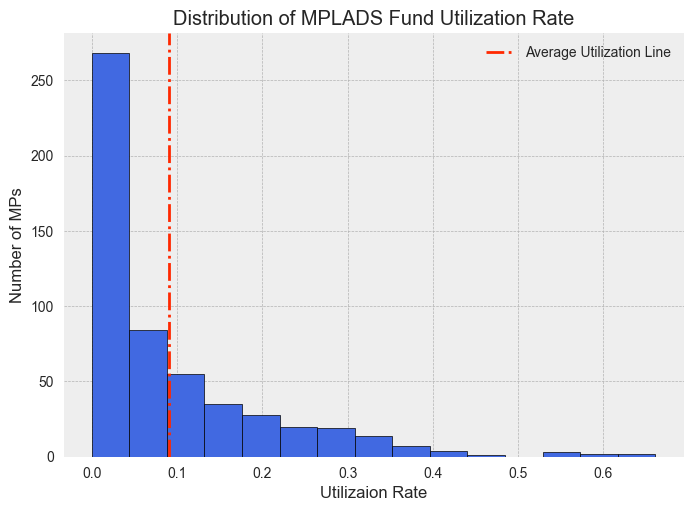

In [99]:
def plot_utlization_rate(df: pd.DataFrame) -> None:
    plt.style.use("bmh")

    plt.hist(df["utiliazation_rate"], bins=15, color="royalblue", edgecolor="black")
    plt.axvline(
        x = np.mean(df["utiliazation_rate"]),
        color="#FF2800",
        linestyle="dashdot",
        linewidth=2,
        label="Average Utilization Line"
    )
    plt.xlabel("Utilizaion Rate")
    plt.ylabel("Number of MPs")
    plt.title("Distribution of MPLADS Fund Utilization Rate")
    plt.legend()
    plt.show()

plot_utlization_rate(df)

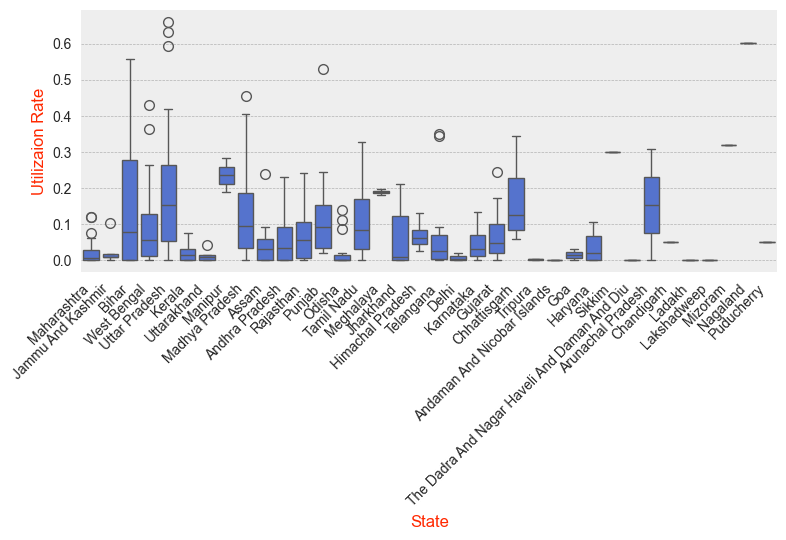

In [125]:
def plot_state_boxplot(df: pd.DataFrame) -> None:
    sns.boxplot(data=df, x="state", y="utiliazation_rate", color="royalblue")
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("State", color="#FF2800")
    plt.ylabel("Utilizaion Rate", color="#FF2800")
    plt.tight_layout()
    plt.show()

plot_state_boxplot(df)

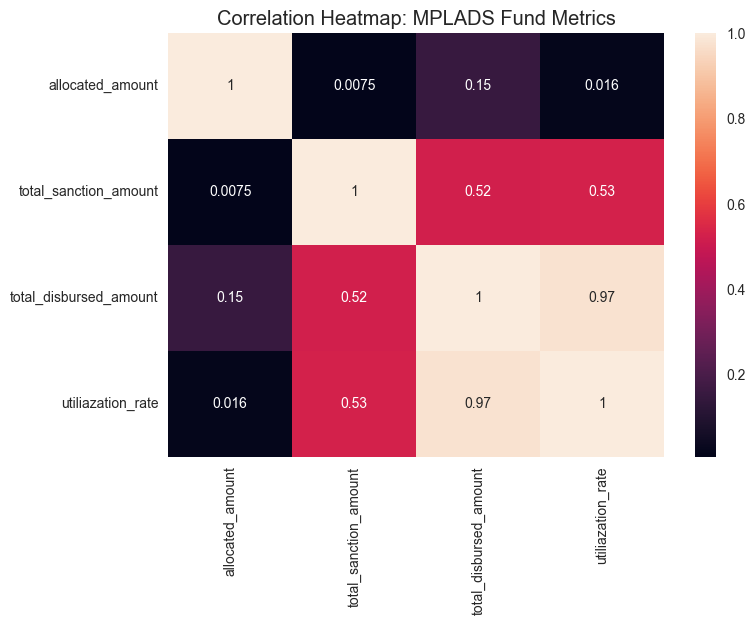

In [148]:
corr_matrix =  df[["allocated_amount", "total_sanction_amount", "total_disbursed_amount", "utiliazation_rate"]].corr()
sns.heatmap(
    corr_matrix, 
    annot=True
)
plt.title("Correlation Heatmap: MPLADS Fund Metrics")
plt.show()

# Low correlation between allocated_amount and total_disbursed_amount
# → more funds allocated does NOT mean more funds get utilized/completed.
# Confirms zero-activity MP finding: money alone isn't the bottleneck.

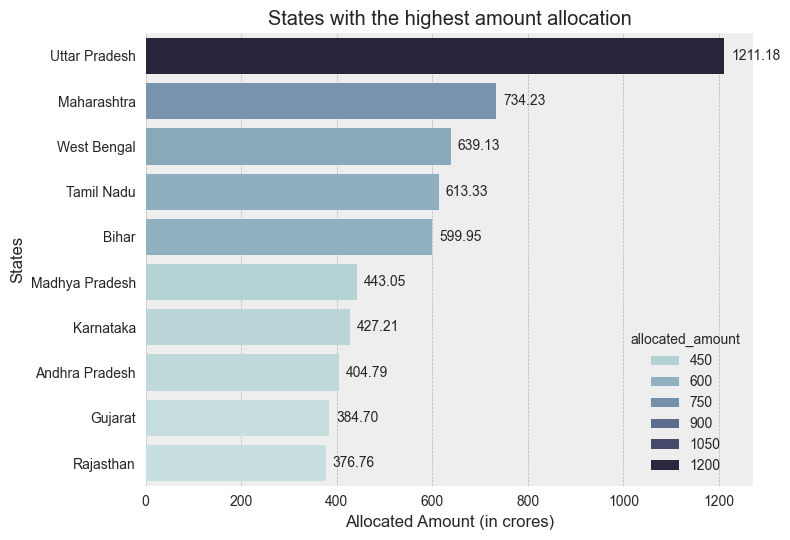

In [182]:
state_total = df.groupby("state")["allocated_amount"].sum().divide(1e7).sort_values(ascending=False).head(10).reset_index()

ax = sns.barplot(
    data=state_total, 
    x="allocated_amount", 
    y="state",
    hue="allocated_amount",
    palette="ch:start=.2,rot=-.3",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=5)

plt.xlabel("Allocated Amount (in crores)")
plt.ylabel("States")
plt.title("States with the highest amount allocation")
plt.tight_layout()
plt.show()

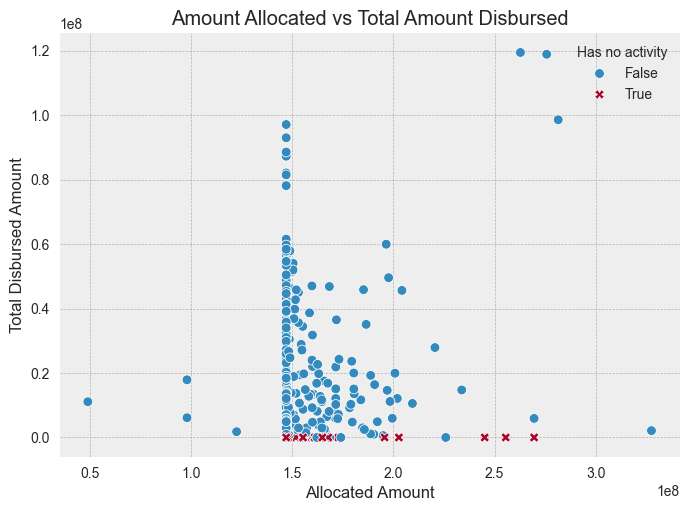

In [206]:
sns.scatterplot(
    data=df,
    x="allocated_amount", 
    y="total_disbursed_amount", 
    hue="has_no_activity", 
    style="has_no_activity"
)

plt.xlabel("Allocated Amount")
plt.ylabel("Total Disbursed Amount")
plt.title("Amount Allocated vs Total Amount Disbursed")
plt.legend(
    title = "Has no activity",
)
plt.show()